<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCPT_Teaser.png" width=100% style="float: right;" alt="PCPT Teaser"></a>
</div>

# Unit 4: Automatic Differentiation

<ul>
    <li><a href='#learn'>Overview and Learning Objectives</a></li>    
    <li><a href='#gradient'>Introduction to Gradient Computation</a></li>
    <li><a href='#toy'>Toy Example</a></li>        
    <li><a href='#gradientdescent'>Gradient Descent</a></li>    
    <li><a href='#polynomialregression'>Polynomial Regression</a></li>
    <li><a href='#autograd'>Autograd Functionality</a></li>    
    <li><a href='#furthernotes'>Further Notes</a></li>
    <li><a href='#exercises'>Exercises</a></li>    
    <ul>
        <li><a href='#exercise_1'>Exercise 1: Learning rate</a></li>
        <li><a href='#exercise_2'>Exercise 2: </a></li>    
        <li><a href='#exercise_3'>Exercise 3: </a></li>         
    </ul>       
</ul> 

<a id='learn'></a> 
<div class="alert alert-block alert-warning">
<h2>Overview and Learning Objectives</h2>

This unit serves as an introduction to <strong>gradient computation</strong>, <strong>gradient descent</strong>, and <strong>automatic differentiation</strong> within the context of optimizing neural networks using PyTorch. Specifically, we will introduce the <code>torch.autograd</code> engine as the primary tool for automating gradient computations. This engine operates internally on <strong>computational graphs</strong>, with nodes representing tensors and edges indicating functions that transform input tensors into output tensors. PyTorch automatically computes gradients by tracing back through this graph, employing the chain rule. To enhance understanding, we provide a toy example of a one-layer linear neural network, demonstrating manual gradient computation to peek under the hood. Additionally, we use <strong>polynomial regression</strong> as a case study for training a linear model, emphasizing key concepts of gradient descent, such as parameter optimization updates and the role of learning rates. Furthermore, we demonstrate how to utilize <code>torch.autograd</code> for automatic gradient computation, highlighting the use of PyTorch tensors, <code>requires_grad</code> settings, and the necessity of <strong>resetting gradients</strong> to zero after each update. The exercises offer opportunities to deepen comprehension by modifying and testing the introduced code.
</div>  

<a id='gradient'></a>  
## Introduction to Gradient Computation

In deep learning, gradient descent is the most prominent optimization algorithm to minimize the cost or loss function of a neural network model. In general, the **gradient**  is a vector that contains partial derivatives of a multivariable function with respect to each of its input variables. It provides important information about how the function changes in the neighborhood of a specific point. In particular, the gradient vector points in the direction of the steepest ascent of the function at a given point. In other words, moving in the negative direction of the gradient, the function will decrease the most rapidly. This is the underlying idea of **gradient descent**, as explained in the <a href='#textbox_gradientdescent'>textbox below</a>.

Therefore, computing the gradient of a differentiable function is of foremost importance when optimizing a neural network. To this end, PyTorch provides the differentiation engine called [`torch.autograd`](https://pytorch.org/docs/stable/autograd.html) to perform automatic gradient computations for any computational graph. Conceptually, a neural network can be represented by a [**directed acyclic graph**](https://en.wikipedia.org/wiki/Directed_acyclic_graph) (**DAG**):

* The DAG defines the network's **forward pass**.
* The nodes are tensors and edges are functions that produce output tensors from input tensors. 
* In the DAG, the **leaves** are the input tensors and the **roots** are the output tensors.

By tracing back this graph from roots to leaves, `torch.autograd` automatically computes the gradients using the chain rule. In this context, the following concepts are important:

* To enable differentiation in the neural network, one needs to declare the tensors for which gradients are to be computed using the `requires_grad=True` keyword. These tensors constitute the **trainable** or **learnable** parameters of the network, typically encompassing weights and biases.

* Each tensor possesses a `.grad_fn` attribute that points to a function responsible for its creation. Each tensor possesses a `.grad_fn` attribute that points to a function responsible for its creation. This concept allows for tracing back computations and is primarily employed internally for the purpose of backpropagation.

* When the `.backward()` function is called on the DAG root, `torch.autograd` computes the gradients from each `.grad_fn`, accumulates them in the respective tensor's `.grad` attribute using the chain rule, and propagates all the way to the leaf tensors.

* The final gradients of the output tensors (associated with the root nodes) with respect to the learnable input tensors (the leaves with `requires_grad=True`) are stored in the `.grad` attribute of the leaf nodes. For example, if `w` is a learnable input tensor that has `w.requires_grad=True` then `w.grad` is another tensor containing the gradient of the output tensors with respect to `w`.

<div class="alert alert-block alert-warning">
<strong>Note:</strong> The terminology can be a source of confusion, as it is important to make a clear distinction between the <strong>input of a network</strong> and the <strong>input of the DAG</strong>. For example, in a linear neural network, the input tensor of the network is typically represented as tensor  <code>x</code>, whereas the training parameters consist a weight tensor <code>w</code> and a bias tensor <code>b</code>. Within the DAG, the leaf nodes correspond to the learnable tensors <code>w</code> and <code>b</code>, while the network's input tensor  <code>x</code> is treated as a fixed value when computing gradients.       
</div>

<a id='toy'></a> 
## Toy Example 

Let's examine the following basic toy example of a one-layer linear neural network that is optimized with respect to a specific loss function.

* The input of the network is given by the tensor `x` and the target is given by the tensor `y`.
* The tensor `w` (weights) and the tensor `b` (bias) correspond to the network's trainable parameters and are to be optimized with regard to some loss function.
* For the trainable parameters, one needs to set the `requires_grad` property of `w` and `b`. This can be done in the initialization or later as (e.g., `w.requires_grad_(True)`).
* A reference to the backward propagation function is stored in the `grad_fn` property of each tensor.
* To compute the gradient, one needs to call the `loss.backward()` function.

In the following code cell, the output of the network is denoted by `z` (which is regarded to be a function of `w` and `b`). Furthermore, we use the root mean square (RMS) as the `loss` function between the output `z` and the target `y`.

In [1]:
import os    
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [2]:
import torch

x = torch.tensor([[2.,3.]])
y = torch.tensor([[0.]])
w = torch.ones(2, 1, requires_grad=True)
b = torch.ones(1,1, requires_grad=True)
z = torch.matmul(x, w) + b
loss = torch.square(z - y).sum()

print(f"z: {z}")
print(f"Gradient function for z: {z.grad_fn}")
print(f"loss: {loss}")
print(f"Gradient function for loss: {loss.grad_fn}")

loss.backward(retain_graph=True)
print(f"w: {w.grad}")
print(f"b: {b.grad}")

z: tensor([[6.]], grad_fn=<AddBackward0>)
Gradient function for z: <AddBackward0 object at 0x0000020984490850>
loss: 36.0
Gradient function for loss: <SumBackward0 object at 0x0000020984490850>
w: tensor([[24.],
        [36.]])
b: tensor([[12.]])


<div class="alert alert-block alert-warning">
<strong>Note:</strong> The <code>grad</code> attribute can be obtained only for the leaf nodes of the computational graph (in our example, <code>w</code> and <code>b</code>). For all other internal nodes of the DAG (e.g., <code>z</code> in our example), the gradients are not accessible.
</div>

We can confirm this outcome by manually calculating the network output `z` and the gradient of `loss` with respect to `w` and `b`. For our example, the tensor `z` is simply a real number denoted by $z$. By abuse of notation, we treat $z$ as a function $z= z(w_0,w_1,b)$, which depends on the parameters $w_0$, $w_1$, and $b$.

$$z = z(w_0,w_1,b) = x_0 \cdot w_0 + x_1 \cdot w_1 + b = 2\cdot 1 +   3\cdot 1 + 1 = 6$$

The loss function is given by:

$$\mathcal{L}(z) = z^2 = 36$$

The gradient of the loss function $\mathcal{L}$ with respect to the parameters $w_0$, $w_1$ and $b$ are obtained using the chain rule:

\begin{eqnarray}
\frac{\partial\mathcal{L}}{\partial w_0}  
&=& \frac{\partial\mathcal{L}}{\partial z} \cdot \frac{\partial z}{\partial w_0} 
= 2\cdot z \cdot x_0 = 2\cdot 6 \cdot 2 = 24 \\
\frac{\partial\mathcal{L}}{\partial w_1}
&=& \frac{\partial\mathcal{L}}{\partial z} \cdot \frac{\partial z}{\partial w_1} 
= 2\cdot z \cdot x_1 = 2\cdot 6 \cdot 3 = 36 \\
\frac{\partial\mathcal{L}}{\partial b}
&=& \frac{\partial\mathcal{L}}{\partial z} \cdot \frac{\partial z}{\partial b}
= 2\cdot z \cdot 1 = 2\cdot 6 = 12
\end{eqnarray}

Thus, the gradient $\nabla{\varphi}$ at $(w_0,w_1,b)$ is given by
$$
\nabla{\varphi}(w_0,w_1,b) = (24,36,12)^\top
$$

<a id='gradientdescent'></a> 
## Gradient Descent

<a id='textbox_gradientdescent'></a>
<div class="alert alert-block alert-success">    
<strong>Recap: Gradient Descent</strong><br>
Gradient descent is an optimization algorithm to find a local minimum of a differentiable function. This technique is often used in machine learning to minimize the cost or loss function of a model. In the following, we recall the main idea of gradient descent. Suppose that we have a function 
    
$$
    \varphi:\mathbb{R}^D\to\mathbb{R}
$$
    
which depends on $D$ variables, say $u_1,\ldots,u_D$. When the function $\varphi$ is differentiable, one can compute the derivative with respect to one of those variables, with the others held constant. This yields a <strong>partial derivative</strong> denoted by $\frac{\partial\varphi}{\partial u_d}$ for each $d\in[1:D]$. Now, if $\varphi$ is differentiable in a neighborhood of a point $p\in\mathbb{R}^D$, 
then the <strong>gradient</strong> $\nabla{\varphi}(p)$ at $p$ is defined as 

$$
    \nabla{\varphi}(p) :=
    \left(\frac{\partial\varphi}{\partial u_1}(p),\ldots,
          \frac{\partial\varphi}{\partial u_D}(p) \right)^\top.
$$  
    
In this case, the function $\varphi$ decreases fastest if one goes 
from $p$ in the direction of the negative gradient 
of $\varphi$ at $p$. Motivated by this property, we define 

$$
    p':=  p - \gamma \cdot \nabla{\varphi}(p)
$$

for some parameter $\gamma\geq 0$, which is also referred to as the <strong>step size</strong> (or  <strong>learning rate</strong>). Then, one can show that $\varphi(p')\leq\varphi(p)$ in the case that the step size $\gamma$ is small enough. Based on this fact, <strong>gradient descent</strong> tries to find a local minimum of $\varphi$ by an iterative approach. Starting with a guess for a local minimum of $\varphi$ at $p^{(0)}\in\mathbb{R}^D$, one iteratively defines

$$
    p^{(k+1)} :=  p^{(k)} - \gamma^{(k)} \cdot \nabla{\varphi}\big(p^{(k)}\big)
$$

for $k=0,1,2,\ldots$. Based on suitable step size parameters $\gamma^{(k)}$, which depend on the properties of $\varphi$ and may be adjusted at every iteration, one obtains

$$
    \varphi\big(p^{(0)}\big)\geq \varphi\big(p^{(1)}\big) \geq \varphi\big(p^{(2)}\big) \geq \ldots
$$

and the sequence $p^{(0)}, p^{(1)},p^{(2)},\ldots$ converges to a local minimum of $\varphi$. With certain assumptions on $\gamma^{(k)}$ and $\varphi$, convergence to a local minimum  can be guaranteed. When the function $\varphi$ is convex, all local minima are also global minima, so in this case gradient descent converges to a global solution.
</div>

Now, let's demonstrate how gradient descent can be employed to optimize the parameters of a neural network. To illustrate this process, we'll focus on the task of optimizing the coefficients of a second-order polynomial in order to approximate a predefined target function.

* Let `x` be the input tensor and `y` the target tensor .
* Let `y_pred =  a + b * x + c * x**2` be the output (also called **prediction**) of the network having three trainable parameters `a`, `b`, and `c`.
* Let `loss` be the root mean square (RMS) to compare `y_pred` and `y`.
* Minimize the loss with regard to `a`, `b`, and `c`.

It is worth noting that this problem falls under the category of **polynomial regression**, which can be solved analytically without the need for gradient descent (as explained in the <a href='#textbox_polynomialregression'>textbox below</a>). However, in the subsequent discussion, we will employ an iterative gradient descent approach to approximate the solution. To begin, we define the input tensor `x`and target tensor `y`, which will act as the training data for optimizing our linear neural network.

In [3]:
import numpy as np
from matplotlib import pyplot as plt

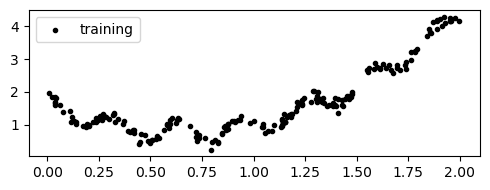

In [4]:
def training_pairs(num=200):
    np.random.seed(seed=0)
    x = np.random.uniform(0,2,num)
    y =  x + 2*(x-0.9)**2 + 0.3*np.cos(20*x) + 0.1*np.random.randn(num)
    return x, y

def plot_result(x_train, y_train, para=None):
    plt.figure(figsize=(5, 2))
    plt.scatter(x_train, y_train, color='black', marker='.', label='training')
    if para:
        x_val = np.linspace(0, 2, 100)
        y_val = para[0] + para[1] * x_val + para[2] * x_val ** 2
        plt.plot(x_val, y_val, color='red', linewidth=2.0, linestyle='-', label='validation')
    plt.tight_layout()
    plt.legend(loc='upper left')

x, y = training_pairs()

plot_result(x, y)

Before applying the `.autograd` differentiation engine, we first provide an implementation where we explicitly compute the gradients. In the following code cell, we perform the following steps: 

* Initializing trainable parameters (**weights**) with random values. 
* Specifying the step size (referred to as the **learning rate**) and the number of iterations (referred to as **epochs**).
* With each iteration:
  * Calculating the prediction (forward path).
  * Computing the loss.
  * Calculating the gradient.
  * Performing a gradient descent step. 
  
Finally, alongside to the original training&ndash;target pairs, we visualize the output of the trained neural network using validation data.

Iteration: 500, Loss: 27.31748758896107
Iteration: 1000, Loss: 19.452964696251428
Iteration: 1500, Loss: 15.256576008991187
Iteration: 2000, Loss: 13.017439609341011
Result: a = 1.3964, b = -2.037, c = 1.7312


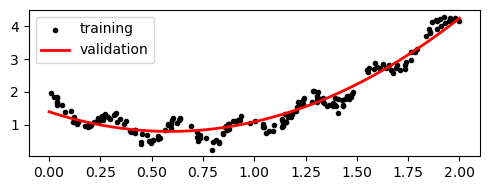

In [5]:
# Initialize weights
np.random.seed(seed=0)
[a,b,c]  = np.random.randn(3)

learning_rate = 1e-4
num_iterations = 2000
for k in range(1,num_iterations+1):
    # Forward pass: compute y_pred
    y_pred = a + b * x + c * x ** 2
    
    # Compute and print loss
    loss = np.square(y_pred - y).sum()
    if k % 500 == 0:
        print(f"Iteration: {k}, Loss: {loss}", flush=True)      

    # Backprop to compute gradients of a, b, c with respect to loss
    grad_y_pred = 2.0 * (y_pred - y)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x ** 2).sum()

    # Update weights
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    
print(f'Result: a = {a:6.4f}, b = {b:6.4}, c = {c:6.4f}')
plot_result(x, y, [a,b,c])

<a id='polynomialregression'></a> 
## Polynomial Regression

<a id='textbox_polynomialregression'></a>
<div class="alert alert-block alert-success">    
<strong>Recap: Polynomial Regression</strong><br>
<a href="https://en.wikipedia.org/wiki/Polynomial_regression">Polynomial regression</a> is  statistical method used to estimate a polynomial relationship between one or more independent variables and a dependent variable (which is also called the target variable). Imagine you have pairs of numbers, like $(x_n,y_n)$, where $x_n\in\mathbb{R}$ can be any real number (input) and $y_n\in\mathbb{R}$ is another real number (target) for $n\in[1:N]$. Let us assume that there is connection between these numbers that can be explained by a polynomial equation with a degree represented by the number $D\in\mathbb{N}$. For coefficients $(c_0,c_1,\ldots,c_D)^\top$, we define the predicted values $z_n$ by 
    
$$
z_n = c_0 + c_1 x_n + c_2 x_n^2 + ... + c_D x_n^D.
$$  
    
The object of polynomial regression is to compute coefficients that minimize the RMS loss 
    
$$
   \sum_{n=1}^N \lVert z_n-y_n\lVert^2
$$
    
between the target values $y_n$ and the predicted values $z_n$. It can be shown that this optimization problem has an analytic solution, which can be expressed using matrix operations. Let $\mathbf{y}:=(y_1,y_1,\ldots,y_N)^\top$ be the vector of target values, $\mathbf{c}:=(c_0,c_1,\ldots,c_D)^\top$ the vector of coefficients, and $\mathbf{X}\in\mathbb{R}^{N\times D}$ the so-called <strong>design matrix</strong> defined by
    
$$
\mathbf{X} = \begin{bmatrix}
1 & x_1 & x_1^2 & \ldots & x_1^D \\
1 & x_2 & x_2^2 & \ldots & x_2^D \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_N & x_N^2 & \ldots & x_N^D \\
\end{bmatrix}.
$$
    
Then the optimal solution $\mathbf{c}^{\ast}$ for the polynomial regression problem is given by
    
$$
   \mathbf{c}^{\ast} = \left(\mathbf{X}^\top \mathbf{X}\right)^{-1} \mathbf{X}^\top \mathbf{y}.
$$

Now, we compare how close the approximation achieved by the linear model trained using gradient descent is to the optimal solution derived from polynomial regression. It is important to mention that we stopped training after 2000 iterations. Given that polynomial regression is a convex optimization problem, a better approximation could have been achieved with additional iterations, provided an appropriate learning rate is used.

Prediction: a = 1.3964, b = -2.037, c = 1.7312
Regression: a = 1.6900, b = -2.808, c = 2.0963
Prediction loss:   13.0174
Regression loss:   10.4558


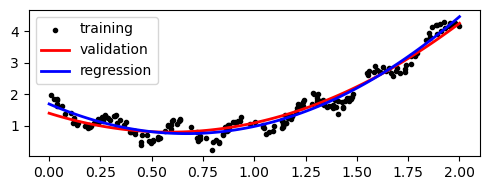

In [6]:
X_design = np.ones((len(x),3))
X_design[:,1] = x
X_design[:,2] = x**2
coef = (np.linalg.inv(X_design.T @ X_design) @ X_design.T) @ y
print(f'Prediction: a = {a:6.4f}, b = {b:6.4}, c = {c:6.4f}')
print(f'Regression: a = {coef[0]:6.4f}, b = {coef[1]:6.4}, c = {coef[2]:6.4f}')
print(f'Prediction loss: {loss:9.4f}')
y_regr = coef[0] + coef[1] * x + coef[2] * x** 2
loss_regr = np.square(y_regr - y).sum()
print(f'Regression loss: {loss_regr:9.4f}')

plot_result(x, y, [a,b,c])
x_val = np.linspace(0, 2, 100)
y_val = coef[0] +  coef[1] * x_val +  coef[2] * x_val ** 2
plt.plot(x_val, y_val, color='blue', linewidth=2.0, linestyle='-', label='regression')
plt.legend(loc='upper left');

<a id='autograd'></a> 
## Autograd Functionality

Expanding upon our previous example, we will now illustrate how to leverage the `torch.autograd` functionality for automatic gradient computation. Please take note of the following aspects in the upcoming code cell:

* Utilize PyTorch tensors instead of NumPy arrays.
* When setting `requires_grad=True`, it instructs `torch.autograd`  to compute gradients for these parameters (in our example, `a`, `b`, and `c`). 
* When calling  `loss.backward()`, it calculates the gradient. Following thiscall, you can access the gradient of the loss with respect to `a`, `b`, and `c` using `a.grad`, `b.grad`and `c.grad`, respectively.
* The gradient update is wrapped within a  `torch.no_grad()` block because, during this step, we do not want to track gradient information for gradient descent using `.autograd`.
* After each gradient descent step, it is essential to reset the gradients to zero (or `None`). The reason is that PyTorch **accumulates gradients** by default. 

Iteration: 500, Loss: 34.500214080343
Iteration: 1000, Loss: 23.285569252983553
Iteration: 1500, Loss: 17.301607454292128
Iteration: 2000, Loss: 14.108638905952207
Iteration: 2500, Loss: 12.404925858181977
Iteration: 3000, Loss: 11.495840147604408
Iteration: 3500, Loss: 11.010760282279534
Iteration: 4000, Loss: 10.751931743811076
Iteration: 4500, Loss: 10.613824889362393
Iteration: 5000, Loss: 10.54013293590967
Iteration: 5500, Loss: 10.500814074193375
Iteration: 6000, Loss: 10.479833143304571
Iteration: 6500, Loss: 10.468637432121017
Iteration: 7000, Loss: 10.462662882479238
Iteration: 7500, Loss: 10.459474300310902
Iteration: 8000, Loss: 10.4577722935268
Iteration: 8500, Loss: 10.456863911690705
Iteration: 9000, Loss: 10.456378792751249
Iteration: 9500, Loss: 10.456119609015367
Iteration: 10000, Loss: 10.455981121202008
Result: a = 1.6877, b = -2.802, c = 2.0934


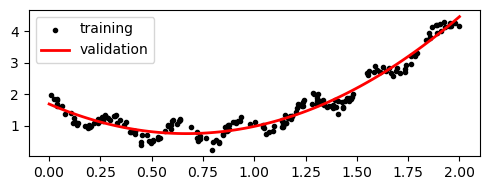

In [7]:
# Initialize weights
dtype = torch.float
torch.manual_seed(1)
a = torch.randn((), dtype=dtype, requires_grad=True)
b = torch.randn((), dtype=dtype, requires_grad=True)
c = torch.randn((), dtype=dtype, requires_grad=True)

x, y = training_pairs()
x = torch.from_numpy(x)
y = torch.from_numpy(y)

learning_rate = 1e-4
num_iterations = 10000
for k in range(1,num_iterations+1):
    # Forward pass: compute y_pred
    y_pred = a + b * x + c * x ** 2
    
    # Compute and print loss
    loss = (y_pred - y).pow(2).sum()
    if k % 500 == 0:
        print(f"Iteration: {k}, Loss: {loss}", flush=True)      

    # Backprop to compute gradients of a, b, c with respect to loss
    loss.backward()

    # Update weights
    with torch.no_grad():    
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
       
    # Manually zero the gradients after updating weights
        a.grad = None
        b.grad = None
        c.grad = None   

print(f'Result: a = {a.item():6.4f}, b = {b.item():6.4}, c = {c.item():6.4f}')
plot_result(x, y, [a.item(),b.item(),c.item()])

As mentioned above, one can stop gradient computations by surrounding the computation code with a `torch.no_grad()` block. 

In [8]:
x = torch.tensor([1,2,3], dtype=torch.float32, requires_grad=True)
z = torch.matmul(x, x)
print(f"z: {z}, requires_grad: {z.requires_grad}")
z.backward()
print(f"gradient: {x.grad}")

with torch.no_grad():
    z = torch.matmul(x, x)
print(f"z: {z}, requires_grad: {z.requires_grad}")
print(f"In this case, calling z.backward() would result in a runtime error.")

z: 14.0, requires_grad: True
gradient: tensor([2., 4., 6.])
z: 14.0, requires_grad: False
In this case, calling z.backward() would result in a runtime error.


There are several reasons why you might want to disable gradient tracking:

* To designate certain parameters in the neural network as fixed or frozen.
* To enhance computational efficiency when you are solely interested in a forward pass (as operations on tensors that do not track gradients are more efficient).

An alternative approach to disabling gradient tracking is by employing  `tensor.detach()`. This function generates a new tensor that is disconnected from the current computation graph and does not have gradient calculations associated with it. Detaching a tensor from a computation graph is also necessary when plotting data using `matplotlib`. This ensures that the plotting process of tensors does not result in unwanted gradient tracking, which has the potential to increase memory usage and computational overhead.

In [9]:
x = torch.tensor([1,2,3], dtype=torch.float32, requires_grad=True)
z = torch.matmul(x, x)
print(f"z: {z}, requires_grad: {z.requires_grad}")

z = z.detach()
print(f"z: {z}, requires_grad: {z.requires_grad}")

z: 14.0, requires_grad: True
z: 14.0, requires_grad: False


<a id='furthernotes'></a> 
## Further Notes

* For further reading, we recommend the unit [Automatic Differentiation with <code>torch.autograd</code>](https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html), which is part of the tutorial [Introduction to PyTorch](https://pytorch.org/tutorials/beginner/basics/intro.html). 

* In this unit, we have explored a basic variant of gradient descent, which is the core of optimization in PyTorch. However, this gradient descent several challenges and limitations. First, it is susceptible to getting stuck in **local minima**, which are points in the optimization landscape where the gradient is zero but the function may not be at its global minimum. Then, it crucially depends on parameters such as the **learning rate** and the **initialization** of the learnable parameters. Furthermore, there is the problem of **vanishing and exploding gradients**. To mitigate these issues, variations of gradient descent, such as stochastic gradient descent (SGD), Adam and RMSprop, have been developed. However, choosing the right optimization algorithm and tuning its hyperparameters remain important aspects of training machine learning models

<a id='exercises'></a> 
## Exercises

<a id='exercise_1'></a>
<div class="alert alert-block alert-info">    
<strong>Exercise 1: Learning rate</strong><br>
Modify the learning rate (<code>learning_rate</code>) in the given example with different values, such as:
Set the learning rate  in the above example to different values including:
<ul>
    <li><code>learning_rate = 1e-3</code></li>    
    <li><code>learning_rate = 1e-4</code></li>
    <li><code>learning_rate = 1e-5</code></li>
</ul>
    
What can you observe? Additionally, experiment with the number of iteration (<code>num_iterations</code>) to further investigate how it impacts the training process. How does this compare to the optimal solution?
</div>

<a id='exercise_2'></a>
<div class="alert alert-block alert-info">
<strong>Exercise2: Gradient</strong><br>
What is happening when the gradient is not reset to zero?
</div>

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCPT_License.png" width=100% style="float: right;" alt="PCPT License"></a>
</div>